<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 121)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.3829 acc 0.290 | val loss 1.3730 acc 0.315 *


[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.3683 acc 0.309 | val loss 1.3374 acc 0.310 *


[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.3230 acc 0.307 | val loss 1.2526 acc 0.310 *


[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.2355 acc 0.310 | val loss 1.1832 acc 0.340 *


...

[ResNet-50] Epoch  32/100 | LR: 2.68e-05 | train loss 0.2346 acc 0.879 | val loss 0.5684 acc 0.783


[ResNet-50] Epoch  33/100 | LR: 2.68e-05 | train loss 0.2305 acc 0.880 | val loss 0.5749 acc 0.783


[ResNet-50] Epoch  34/100 | LR: 2.68e-06 | train loss 0.2469 acc 0.879 | val loss 0.5633 acc 0.798


[ResNet-50] Epoch  35/100 | LR: 2.68e-06 | train loss 0.2118 acc 0.909 | val loss 0.5669 acc 0.793


[ResNet-50] Epoch  36/100 | LR: 2.68e-06 | train loss 0.1942 acc 0.912 | val loss 0.5799 acc 0.798

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 36.

[ResNet-50] Restored best checkpoint (val loss = 0.5609)


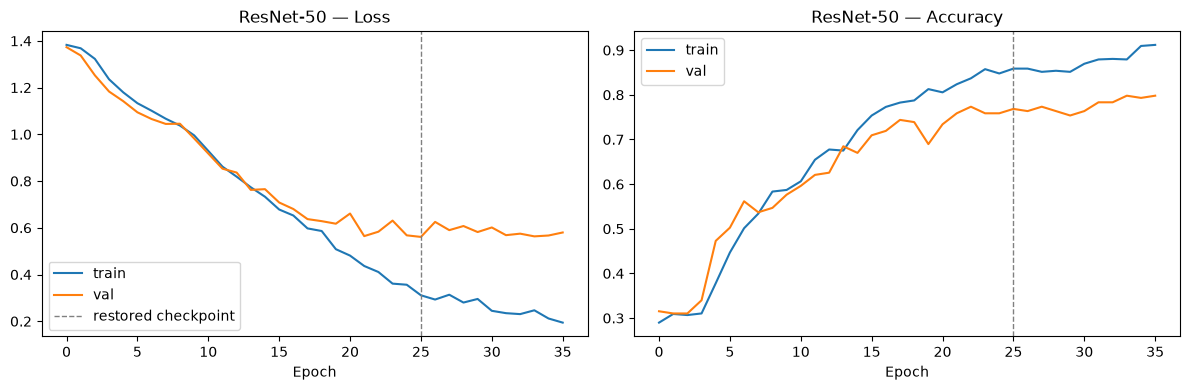

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.694


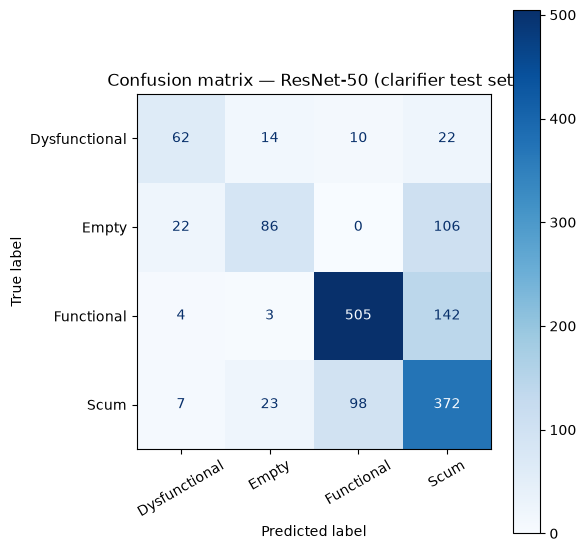

               precision    recall  f1-score   support

Dysfunctional      0.653     0.574     0.611       108
        Empty      0.683     0.402     0.506       214
   Functional      0.824     0.772     0.797       654
         Scum      0.579     0.744     0.651       500

     accuracy                          0.694      1476
    macro avg      0.685     0.623     0.641      1476
 weighted avg      0.708     0.694     0.692      1476



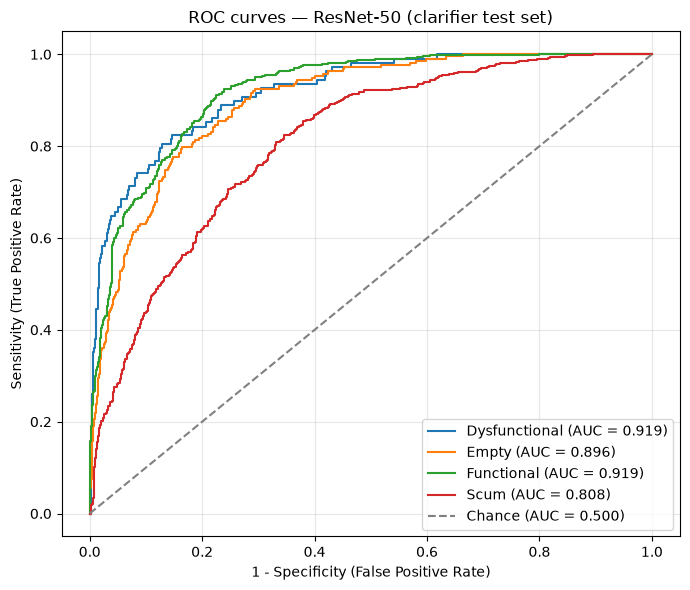

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.919
  Empty          : 0.896
  Functional     : 0.919
  Scum           : 0.808

Mean AUC (over 4/4 classes with test examples): 0.885


(np.float64(0.6944444444444444),
 {'Dysfunctional': 0.919103313840156,
  'Empty': 0.8956855310514389,
  'Functional': 0.9186588986361303,
  'Scum': 0.8079159836065575})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_CapeFlats.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
